**## Instalasi Package**

In [ ]:
! "E:\Semester 5\Praktikum\PA KB N MOBILE\.venv\Scripts\python.exe" -m pip install tensorflow matplotlib scikit-learn pandas tqdm pydot seaborn

# Cell 1: INSTALASI PACKAGE YANG DIPERLUKAN
# 
# Tujuan: Menginstall semua dependencies yang diperlukan untuk proyek machine learning
# Package yang diinstall:
# - tensorflow    : Framework deep learning untuk membangun dan melatih model CNN
# - matplotlib    : Library visualisasi data untuk plotting dan grafik
# - scikit-learn  : Machine learning utilities untuk preprocessing dan evaluasi
# - pandas        : Manipulasi data terstruktur (DataFrame)
# - tqdm          : Progress bar untuk monitoring proses iterasi
# - pydot         : Visualisasi arsitektur model neural network
# - seaborn       : Visualisasi data statistik yang enhanced
#
# Catatan: Menggunakan Python dari virtual environment untuk isolasi dependencies

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


<!-- Kegunaan: Menginstall package Python yang diperlukan untuk proyek
Logika: Menjalankan pip install menggunakan Python dari virtual environment untuk menginstall:

tensorflow - untuk deep learning

matplotlib - untuk visualisasi data

scikit-learn - untuk machine learning

pandas - untuk manipulasi data

tqdm - untuk progress bar

pydot - untuk visualisasi model

seaborn - untuk visualisasi data statistik -->

**# 1. PREPROCESSING DATA MENJADI 3 VAL, TEST DAN TRAIN**

In [ ]:
import os


# Cell 2: IMPORT MODULE OS
# 
# Tujuan: Mengimport module OS untuk operasi sistem file
# Fungsi: 
# - Navigasi direktori dan manipulasi path
# - Membaca struktur folder dataset
# - Operasi file management

In [ ]:
mypath= 'E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet_Kecacatan_Jeruk'

# Cell 3: DEFINISI PATH DATASET UTAMA
# 
# Tujuan: Mendefinisikan path menuju dataset gambar jeruk
# Struktur: Dataset berisi folder-folder berdasarkan jenis kecacatan jeruk
# Lokasi: E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet_Kecacatan_Jeruk

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\User\AppData\Local\Temp\ipykernel_15604\3265040862.py:1: SyntaxWarning: invalid escape sequence '\S'
  mypath= 'E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet_Kecacatan_Jeruk'


In [ ]:
file_name = []
tag = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        tag.append(path.split('\\')[-1])
        file_name.append(name)
        
# Cell 4: EKSTRAKSI INFORMASI FILE DARI STRUKTUR DIREKTORI DATASET
# 
# Tujuan: 
# - Mengumpulkan metadata semua file gambar (nama file, path lengkap, dan label)
# - Label diambil otomatis dari nama folder (asumsi: setiap folder = satu kelas)
# - Menyiapkan data untuk pembagian train/val/test sets
#
# Variabel yang dibuat:
# file_name    -> Menyimpan nama file saja (contoh: 'b-1-_jpg.rf.3be2b71cfabb843f9c1e1cb1e4d8397f.jpg')
# tag          -> Menyimpan label/kategori berdasarkan nama folder terakhir (contoh: 'Blackspot')
# full_path    -> Menyimpan path lengkap menuju file (contoh: 'E:\...\Blackspot\b-1-.jpg')
#
# Penjelasan looping:
# 1. os.walk(mypath) -> Traverse rekursif seluruh struktur direktori dataset
#    - Mengembalikan 3 nilai: path (direktori saat ini), subdirs (subdirektori), files (file-file)
# 2. for name in files -> Iterasi melalui setiap file dalam direktori saat ini
#
# Proses dalam loop:
# - full_path.append(os.path.join(path, name)) -> Gabungkan path direktori + nama file untuk dapat path lengkap
# - tag.append(path.split('\\\\')[-1])          -> Split path berdasarkan '\\', ambil elemen terakhir sebagai label
#   Contoh: 'E:\DataSet\Blackspot' -> split -> ['E:', 'DataSet', 'Blackspot'] -> [-1] = 'Blackspot'
# - file_name.append(name)                     -> Simpan nama file saja
#
# Struktur dataset asumsi:
# DataSet_Kecacatan_Jeruk/
# ├── Blackspot/   (184 images)
# ├── Cancer/      (179 images)  
# ├── Fresh/       (281 images)
# └── Grenning/    (347 images)


In [ ]:
import pandas as pd

# Cell 5: IMPORT PANDAS UNTUK MANIPULASI DATA
# 
# Tujuan: Mengimport pandas untuk bekerja dengan data terstruktur
# Fungsi:
# - Membuat DataFrame dari list yang telah diekstrak
# - Analisis dan manipulasi data
# - Pembagian dataset

In [ ]:
# memasukan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapih
df = pd.DataFrame({'path': full_path, 'file_name': file_name, "tag": tag})
df.groupby(['tag']).size()


# Cell 6: MEMBUAT DATAFRAME DAN ANALISIS DISTRIBUSI KELAS
# 
# Tujuan: 
# - Membuat DataFrame terstruktur dari metadata yang telah dikumpulkan
# - Menganalisis distribusi jumlah gambar per kelas
#
# Proses:
# - pd.DataFrame() -> Membuat DataFrame dengan 3 kolom: path, file_name, tag
# - df.groupby(['tag']).size() -> Menghitung jumlah sampel per kelas
#
# Output yang diharapkan:
# Blackspot    184
# Cancer       179  
# Fresh        281
# Grenning     347

tag
Blackspot    184
Cancer       179
Fresh        281
Grenning     347
dtype: int64

In [ ]:
df.head()

# Cell 7: INSPEKSI DATA SAMPLE
# 
# Tujuan: Menampilkan 5 baris pertama DataFrame untuk memverifikasi data
# Fungsi: Memastikan struktur DataFrame sudah benar sebelum processing lanjutan

,path,file_name,tag
0,E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet...,b-1-_jpg.rf.3be2b71cfabb843f9c1e1cb1e4d8397f.jpg,Blackspot
1,E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet...,b-10-_jpg.rf.4b35cd5a9ddcf53541c6d727cc41fdbd.jpg,Blackspot
2,E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet...,b-100-_jpg.rf.11e7872044cd83ddd470b1199fd31bdd...,Blackspot
3,E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet...,b-101-_jpg.rf.e1afe1f2a180fae868a1b5b8d9669fe5...,Blackspot
4,E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet...,b-102-_jpg.rf.dacbee2f7eda185b261819e0b8e43772...,Blackspot


In [ ]:
from sklearn.model_selection import train_test_split

# Cell 8: IMPORT FUNGSI PEMBAGIAN DATASET
# 
# Tujuan: Mengimport fungsi train_test_split dari scikit-learn
# Fungsi: Untuk membagi dataset menjadi training, validation, dan test sets

In [ ]:
#Split data train dan test
X = df['path']
Y = df['tag']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=300)

# Cell 9: PEMBAGIAN DATA TRAIN DAN TEST
# 
# Tujuan: Membagi dataset menjadi training set (80%) dan test set (20%)
# Parameter:
# - X = df['path'] -> Features (path file gambar)
# - Y = df['tag']  -> Labels (kategori kecacatan)
# - test_size=0.20 -> 20% data untuk testing
# - random_state=300 -> Seed untuk reproducibility (hasil konsisten setiap run)
#
# Hasil: 
# - X_train, y_train -> 80% data untuk training
# - X_test, y_test   -> 20% data untuk testing

In [ ]:
#split data test menjadi 2 yaitu data test dan data validation
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=100)

# Cell 10: PEMBAGIAN DATA TEST MENJADI VALIDATION DAN TEST
# 
# Tujuan: Membagi data test menjadi validation set dan test set (masing-masing 10% dari total)
# Parameter:
# - test_size=0.50 -> 50% dari data test dialokasikan untuk validation
# - random_state=100 -> Seed berbeda untuk variasi pembagian
#
# Hasil akhir distribusi:
# - Training set: 80% dari total (792 images)
# - Validation set: 10% dari total (100 images) 
# - Test set: 10% dari total (99 images)

In [ ]:
#ini gabungkan framenya
df_train = pd.DataFrame({
    'path': X_train,
    'tag': y_train,
    'set':'train'
    })

df_test = pd.DataFrame({
    'path': X_test,
    'tag': y_test,
    'set':'test'
    })

df_validation = pd.DataFrame({
    'path': X_val,
    'tag': y_val,
    'set':'val'
    })

# Cell 11: MEMBUAT DATAFRAME TERPISAH UNTUK SETIAP SUBSET
# 
# Tujuan: Membuat DataFrame terpisah untuk training, validation, dan test sets
# Fungsi: 
# - Memudahkan management data selama training
# - Menambahkan kolom 'set' untuk identifikasi
#
# DataFrame yang dibuat:
# - df_train -> Data training dengan kolom tambahan 'set':'train'
# - df_test  -> Data testing dengan kolom tambahan 'set':'test'  
# - df_validation -> Data validation dengan kolom tambahan 'set':'val'


#Tampilkan berapaa isi dari masing masing pathnya hasil bagi
print('train size', len(df_train))
print('val size', len(df_validation))
print('test size', len(df_test))


# Cell 12: MENAMPILKAN UKURAN SETIAP SUBSET
# 
# Tujuan: Menampilkan jumlah data di setiap subset untuk verifikasi
# Output yang diharapkan:
# train size 792
# val size 100  
# test size 99


train size 792
val size 100
test size 99


In [ ]:
#gabungkan biar dapat trainnya, testnya, valnya
df_all = pd.concat([df_train, df_test, df_validation], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set','tag']).size(), '\n')

print('===================================================== \n')

df_all.sample(3)


# Cell 13: GABUNGKAN SEMUA SUBSET DAN ANALISIS DISTRIBUSI
# 
# Tujuan: 
# - Menggabungkan semua subset menjadi satu DataFrame lengkap
# - Menganalisis distribusi data per set dan per tag
#
# Proses:
# - pd.concat() -> Menggabungkan df_train, df_test, df_validation
# - groupby(['set','tag']).size() -> Analisis distribusi detail
# - df_all.sample(3) -> Menampilkan 3 sampel random untuk inspeksi



set    tag      
test   Blackspot     14
       Cancer        20
       Fresh         28
       Grenning      37
train  Blackspot    149
       Cancer       143
       Fresh        227
       Grenning     273
val    Blackspot     21
       Cancer        16
       Fresh         26
       Grenning      37
dtype: int64 




,path,tag,set
904,E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet...,Blackspot,val
600,E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet...,Fresh,train
176,E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet...,Fresh,train


In [ ]:
import shutil
from tqdm.notebook import tqdm as tq

# Cell 14: IMPORT UTILITIES UNTUK FILE OPERATIONS
# 
# Tujuan: Mengimport library untuk operasi file dan progress tracking
# - shutil -> Untuk copy, move, dan operasi file sistem
# - tqdm   -> Progress bar untuk monitoring proses yang memakan waktu

In [ ]:
datasource_path = 'E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet_Kecacatan_Jeruk\DataSet_Kecacatan_Jeruk'
dataset_path = 'E:\Semester 5\Praktikum\PA KB N MOBILE\dataset'

# Cell 15: DEFINISI PATH UNTUK ORGANISASI DATASET
# 
# Tujuan: Mendefinisikan path source dan destination untuk reorganisasi file
# - datasource_path -> Path asli dataset (source)
# - dataset_path    -> Path baru untuk dataset terorganisir (destination)

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\User\AppData\Local\Temp\ipykernel_15604\2769839363.py:1: SyntaxWarning: invalid escape sequence '\S'
  datasource_path = 'E:\Semester 5\Praktikum\PA KB N MOBILE\DataSet_Kecacatan_Jeruk\DataSet_Kecacatan_Jeruk'
C:\Users\User\AppData\Local\Temp\ipykernel_15604\2769839363.py:2: SyntaxWarning: invalid escape sequence '\S'
  dataset_path = 'E:\Semester 5\Praktikum\PA KB N MOBILE\dataset'


In [ ]:
from tqdm import tqdm

for index, row in tqdm(df_all.iterrows(), total=len(df_all)):
    
    #nentuin file pathnya
    file_path = row['path']
    if os.path.exists(file_path) == False:
        file_path = os.path.join(datasource_path, row['tag'], row['image'].split('.')[0])
    
    #bikin folder biar sesuai
    dest_dir = os.path.join(dataset_path, row['set'], row['tag'])
    os.makedirs(dest_dir, exist_ok=True)
    
    #ini memberi tujuan untuk foldernya kemana
    destination_file_name = os.path.basename(file_path)
    file_dest = os.path.join(dest_dir, destination_file_name)
    
    #nah ii copynya
    if not os.path.exists(file_dest):
        shutil.copy2(file_path, file_dest)
        
# Cell 16: ORGANISASI FILE KE STRUKTUR DIREKTORI BARU
# 
# Tujuan: Mengcopy file ke struktur direktori baru berdasarkan set dan tag
# Proses:
# 1. Iterasi melalui setiap row di df_all dengan progress bar
# 2. Untuk setiap file:
#    - Cek jika file_path exists, jika tidak reconstruct path
#    - Buat direktori tujuan (dataset_path/set/tag) jika belum ada
#    - Copy file ke direktori tujuan
#
# Struktur hasil:
# dataset/
# ├── train/
# │   ├── Blackspot/
# │   ├── Cancer/
# │   ├── Fresh/
# │   └── Grenning/
# ├── val/
# │   ├── Blackspot/
# │   └── ...
# └── test/
#     ├── Blackspot/
#     └── ...


100%|██████████| 991/991 [00:02<00:00, 334.37it/s]


####
2. MODELING CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing import image
# from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np


# Cell 17: IMPORT LIBRARIES UNTUK MODELING CNN
# 
# Tujuan: Mengimport semua library yang diperlukan untuk membangun dan melatih model CNN
# TensorFlow & Keras:
# - tensorflow.keras -> High-level API untuk neural networks
# - MobileNetV2      -> Pre-trained model untuk transfer learning
# - ImageDataGenerator -> Data augmentation dan preprocessing
# - Sequential       -> Model linear stack of layers
# - Conv2D, MaxPooling2D, Flatten, Dense -> Layer types untuk CNN
#
# Visualisasi dan Utilities:
# - matplotlib.pyplot -> Plotting dan visualisasi
# - numpy             -> Operasi numerik

In [ ]:
train_dir = r"E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\train"
val_dir   = r"E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\val"
test_dir  = r"E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test"

# Cell 18: DEFINISI PATH SETIAP SUBSET DATASET
# 
# Tujuan: Mendefinisikan path untuk setiap subset dataset yang telah diorganisir
# - train_dir -> Path ke training set
# - val_dir   -> Path ke validation set  
# - test_dir  -> Path ke test set

In [ ]:
train_datagen = ImageDataGenerator(rescale=1. / 255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1. / 255,)
test_datagen = ImageDataGenerator(rescale=1. / 255,)


# Cell 19: SETUP IMAGE DATA GENERATOR UNTUK DATA AUGMENTATION
# 
# Tujuan: Membuat data generator dengan augmentasi untuk training dan preprocessing untuk validation/test
#
# Training Data Generator (dengan augmentasi):
# - rescale=1./255     -> Normalisasi pixel values ke range [0,1]
# - shear_range=0.2    -> Transformasi shear (geser) 20%
# - zoom_range=0.2     -> Zoom in/out 20% 
# - horizontal_flip=True -> Flip horizontal secara random
#
# Validation/Test Data Generator (tanpa augmentasi):
# - Hanya rescale untuk normalisasi

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb'
)


# Cell 20: MEMBUAT DATA GENERATORS UNTUK TRAINING DAN VALIDATION
# 
# Tujuan: Membuat generator untuk loading dan preprocessing gambar secara real-time
#
# Parameter generator:
# - directory      -> Path ke direktori gambar
# - target_size=(224,224) -> Resize semua gambar ke 224x224 pixels (standard untuk MobileNetV2)
# - batch_size=32  -> Processing 32 gambar sekaligus (optimasi memory dan training speed)
# - class_mode='categorical' -> Untuk multi-class classification (4 kelas)
# - color_mode='rgb' -> Menggunakan 3 channel warna (Red, Green, Blue)
#
# Output:
# - train_generator -> Generator untuk data training dengan augmentasi
# - val_generator   -> Generator untuk data validation tanpa augmentasi

Found 792 images belonging to 4 classes.
Found 100 images belonging to 4 classes.


3. Visual Image

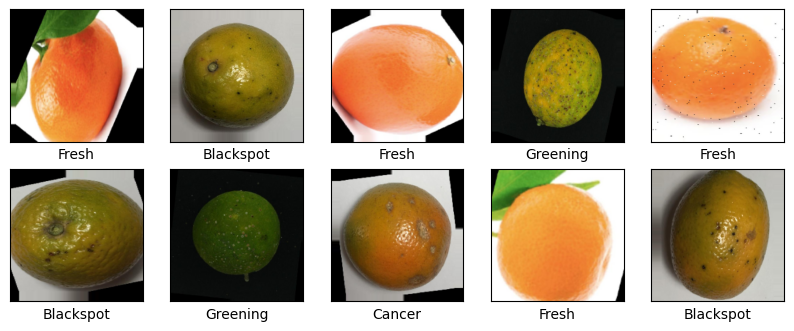

In [ ]:
# Cell 21: VISUALISASI SAMPLE GAMBAR DARI TRAINING GENERATOR
# 
# Tujuan: 
# - Menampilkan 10 sample gambar dari training generator untuk inspeksi visual
# - Memverifikasi bahwa data loading dan preprocessing bekerja dengan benar
# - Memastikan label sesuai dengan gambar yang ditampilkan
# - Visualisasi quick check sebelum memulai training

# Import library untuk plotting
import matplotlib.pyplot as plt
# Definisi nama kelas sesuai dengan urutan di class_indices generator
# Catatan: Urutan harus sama dengan yang digunakan generator
class_names = ["Blackspot", "Cancer", "Fresh", "Greening"]

# Ambil satu batch data dari training generator
# next(train_generator) mengembalikan tuple (images, labels)
# - images: Array numpy berisi batch gambar yang sudah dipreprocess
# - labels: Array numpy berisi one-hot encoded labels
images, labels = next(train_generator)

# Setup figure untuk menampilkan gambar
# figsize=(10, 10) berarti figure berukuran 10x10 inch
plt.figure(figsize=(10, 10))

# Loop melalui 10 gambar pertama dalam batch
for i in range(10):
    
    # Buat subplot dalam grid 5x5 (total 25 slot, tapi kita hanya pakai 10 pertama)
    # i + 1 karena subplot index mulai dari 1, bukan 0
    plt.subplot(5, 5, i + 1)
    
    # Hilangkan ticks pada axes untuk tampilan yang lebih clean
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)# Hilangkan grid background

  # Tampilkan gambar menggunakan imshow()
    # images[i]: Gambar ke-i dalam batch (sudah dalam format [0,1] karena rescale)
    # cmap=plt.cm.binary: Colormap binary (grayscale-like) untuk konsistensi
    plt.imshow(images[i], cmap=plt.cm.binary)
    
# Konversi one-hot encoded label ke index kelas
    # np.argmax(labels[i]) mencari index dengan nilai tertinggi dalam one-hot vector
    # Contoh: [0, 0, 1, 0] -> argmax = 2 (kelas Fresh)
    label_index = np.argmax(labels[i])
    
    # Set xlabel sebagai nama kelas (sebagai annotation di bawah gambar)
    plt.xlabel(class_names[label_index])

# Tampilkan semua gambar dalam satu window
plt.show()

# LOGIKA DAN ALUR CODE:
# 1. Ambil batch data -> Generator menghasilkan batch berisi 32 gambar + labels
# 2. Setup canvas -> Siapkan figure 10x10 inch dengan grid 5x5
# 3. Iterasi 10 gambar -> Untuk setiap gambar dalam batch (hanya 10 pertama):
#    a. Posisikan di subplot yang sesuai
#    b. Hilangkan axes decoration untuk fokus pada gambar
#    c. Tampilkan gambar dengan colormap binary
#    d. Konversi one-hot label ke class name
#    e. Tampilkan class name sebagai label
# 4. Render -> Tampilkan semua gambar sekaligus

# OUTPUT YANG DIHARAPKAN:
# - Grid 5x5 dengan 10 gambar sample (5 baris x 2 kolom terisi, sisanya kosong)
# - Setiap gambar ditampilkan dalam grayscale dengan class name di bawahnya
# - Verifikasi visual bahwa augmentasi bekerja (gambar mungkin ter-rotate/flipped)
# - Konfirmasi bahwa label sesuai dengan konten gambar

# CATATAN PENTING:
# - images[i] sudah dinormalisasi ke range [0,1] karena rescale=1./255
# - labels[i] dalam format one-hot encoded (contoh: [0,1,0,0] untuk kelas Cancer)
# - Urutan class_names HARUS sama dengan urutan di train_generator.class_indices
# - Gambar akan terlihat dalam grayscale karena cmap=plt.cm.binary

In [ ]:
# Cell 22: LOAD PRE-TRAINED BASE MODEL MOBILENETV2
# 
# Tujuan: 
# - Menggunakan transfer learning dengan model MobileNetV2 yang sudah pre-trained pada ImageNet
# - Memanfaatkan feature extraction capabilities yang sudah dilatih pada dataset besar
# - Membangun fondasi yang kuat untuk task klasifikasi spesifik (kecacatan jeruk)

# Load MobileNetV2 model dengan konfigurasi berikut:
base_model = MobileNetV2(
    weights='imagenet',        # Gunakan weights yang sudah dilatih pada ImageNet
    include_top=False,         # Exclude top classification layer (kita akan custom)
    input_shape=(224, 224, 3)  # Input shape: 224x224 pixels, 3 channels (RGB)
)

# PENJELASAN PARAMETER:
# - weights='imagenet': 
#   * Menggunakan weights yang sudah dilatih pada dataset ImageNet (1.2 juta gambar, 1000 kelas)
#   * Memberikan feature extractor yang powerful tanpa perlu training dari scratch
#
# - include_top=False:
#   * TIDAK menyertakan top layer (fully connected layers untuk klasifikasi 1000 kelas ImageNet)
#   * Hanya mengambil convolutional base untuk feature extraction
#   * Memungkinkan kita menambahkan custom classifier untuk 4 kelas kita
#
# - input_shape=(224, 224, 3):
#   * Sesuai dengan target_size yang kita set di ImageDataGenerator (224, 224)
#   * 3 channels untuk gambar RGB
#   * MobileNetV2 default input size adalah 224x224

# KEUNTUNGAN MOBILENETV2:
# - Arsitektur lightweight dan efficient (cocok untuk deployment)
# - Depthwise separable convolution untuk mengurangi computational cost
# - Already learned rich feature representations dari ImageNet
# - Good balance antara accuracy dan speed

# OUTPUT:
# - base_model: Model Keras tanpa top layers, siap untuk ditambahkan custom layers
# - Model sudah memiliki weights optimal untuk feature extraction
# - Siap untuk fine-tuning atau digunakan sebagai fixed feature extractor

# CATATAN:
# Model ini akan berfungsi sebagai feature extractor, dan kita akan menambahkan
# custom dense layers di atasnya untuk klasifikasi 4 jenis kecacatan jeruk

In [ ]:
# Cell 23: MEMBEKUUKAN (FREEZE) BASE MODEL UNTUK TRANSFER LEARNING
# 
# Tujuan: 
# - Mencegah update weights pada base model selama training fase pertama
# - Mempertahankan feature representations yang sudah dipelajari dari ImageNet
# - Hanya melatih custom layers yang akan kita tambahkan di atasnya

# Membekukan seluruh base model - weights tidak akan diupdate selama training
# Membekukan model untuk memastikan bebas tidak berubah saat ditraining
base_model.trainable = False

# PENJELASAN KONSEP FREEZING:
# - Saat trainable=False, semua layer dalam base_model tidak akan diupdate selama backpropagation
# - Gradien tidak akan dihitung untuk layer-layer tersebut
# - Weights akan tetap sama seperti saat pre-trained pada ImageNet

# MENGAPA PERLU FREEZE?
# 1. Mencegah Overfitting:
#    * Dengan jumlah data yang terbatas (991 gambar), training seluruh model bisa menyebabkan overfitting
#    * Base model yang besar (2.3M parameters) mudah overfit pada dataset kecil

# 2. Mempertahankan Feature yang Sudah Dipelajari:
#    * MobileNetV2 sudah belajar feature detectors yang berguna (edges, textures, patterns)
#    * Feature ini umumnya transferable across different image classification tasks

# 3. Training yang Lebih Cepat dan Stabil:
#    * Hanya custom layers yang perlu di-training
#    * Mengurangi computational cost dan memory requirements
#    * Training lebih stabil karena tidak ada perubahan drastic pada base features

# 4. Konvergen Lebih Cepat:
#    * Model mulai dari titik yang sudah optimal untuk feature extraction
#    * Tidak perlu belajar low-level features dari scratch

# STRATEGI TRAINING:
# Fase 1: Base model FROZEN, hanya custom layers yang di-training
# Fase 2 (Fine-tuning): Unfreeze beberapa layer terakhir, training dengan learning rate rendah

In [ ]:
# Cell 24: MEMBUAT CUSTOM CNN MODEL DENGAN ARSITEKTUR SEQUENTIAL
# 
# Tujuan:
# - Membangun model CNN dari scratch untuk klasifikasi 4 jenis kecacatan jeruk
# - Membuat arsitektur sederhana namun efektif untuk task image classification
# - Alternatif approach selain menggunakan transfer learning

# Membuat model Sequential (linear stack of layers)
model = Sequential([
    # LAYER 1: Convolutional Layer dengan 32 filters
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    # 32 filters dengan kernel size 3x3, activation ReLU
    # input_shape=(224,224,3) - menerima gambar 224x224 RGB
    MaxPooling2D(2,2),  # Max pooling 2x2 untuk reduksi dimensi

    # LAYER 2: Convolutional Layer dengan 64 filters  
    Conv2D(64, (3,3), activation='relu'),
    # Meningkatkan ke 64 filters untuk belajar feature yang lebih kompleks
    MaxPooling2D(2,2),  # Max pooling lagi untuk further reduksi

    # LAYER 3: Convolutional Layer dengan 128 filters
    Conv2D(128, (3,3), activation='relu'),
    # 128 filters untuk high-level feature extraction
    MaxPooling2D(2,2),  # Final max pooling

    # TRANSITION: Flatten layer untuk konversi dari 2D ke 1D
    Flatten(),
    # Mengubah feature maps 2D menjadi vector 1D untuk dense layers

    # LAYER 4: Fully Connected Layer dengan 128 neurons
    Dense(128, activation='relu'),
    # Dense layer untuk learning non-linear combinations of features

    # LAYER 5: Output Layer dengan 4 neurons (untuk 4 kelas)
    Dense(4, activation='softmax') 
    # Softmax activation untuk multi-class classification
    # Output: 4 probabilities yang sum to 1 (masing-masing untuk setiap kelas)
])

# PENJELASAN ARSITEKTUR LAYER BY LAYER:

# 1. Conv2D(32, (3,3)) -> MaxPooling2D(2,2):
#    * Input: 224x224x3 -> Output: 112x112x32
#    * Belajar 32 feature maps dasar (edges, corners, simple textures)

# 2. Conv2D(64, (3,3)) -> MaxPooling2D(2,2):  
#    * Input: 112x112x32 -> Output: 56x56x64
#    * Belajar 64 feature maps yang lebih kompleks

# 3. Conv2D(128, (3,3)) -> MaxPooling2D(2,2):
#    * Input: 56x56x64 -> Output: 28x28x128
#    * Belajar 128 high-level feature maps (object parts, patterns)

# 4. Flatten():
#    * Input: 28x28x128 -> Output: 28*28*128 = 100,352 neurons
#    * Konversi dari spatial representation ke vector representation

# 5. Dense(128):
#    * Fully connected layer untuk learning complex feature combinations
#    * 128 neurons dengan ReLU activation

# 6. Dense(4, softmax):
#    * Output layer dengan 4 neurons (sesuai jumlah kelas: Blackspot, Cancer, Fresh, Greening)
#    * Softmax activation untuk probability distribution across classes

# DIMENSIONALITY FLOW:
# Input: (224, 224, 3) = 150,528 pixels
# After Conv1 + Pool1: (112, 112, 32) = 401,408 neurons (setelah flatten akan jadi 401,408)
# After Conv2 + Pool2: (56, 56, 64) = 200,704 neurons  
# After Conv3 + Pool3: (28, 28, 128) = 100,352 neurons
# After Flatten: 100,352 neurons
# After Dense1: 128 neurons
# After Dense2: 4 neurons (output)

# KEUNTUNGAN ARSITEKTUR INI:
# 1. Progressive feature learning: Simple -> Complex features
# 2. Dimensionality reduction melalui max pooling
# 3. Cukup dalam untuk belajar hierarchical features
# 4. Tidak terlalu kompleks untuk dataset berukuran sedang

# KELEMAHAN:
# 1. Butuh lebih banyak data dibanding transfer learning
# 2. Training dari scratch membutuhkan waktu lebih lama
# 3. Mungkin tidak se-robust seperti pre-trained models

# CATATAN:
# Ini adalah alternatif jika tidak menggunakan MobileNetV2
# Untuk hasil terbaik, biasanya transfer learning lebih direkomendasikan untuk dataset kecil

e:\Semester 5\Praktikum\PA KB N MOBILE\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Cell 25: COMPILE MODEL DENGAN OPTIMIZER, LOSS FUNCTION, DAN METRICS
# 
# Tujuan:
# - Mengkonfigurasi model untuk proses training dengan menentukan bagaimana model akan belajar
# - Mendefinisikan optimizer, loss function, dan metrics evaluasi
# - Menyiapkan model untuk fase training

# Compile model dengan konfigurasi berikut:
model.compile(
    optimizer='adam',                    # Optimizer untuk update weights
    loss='categorical_crossentropy',    # Loss function untuk multi-class classification
    metrics=['accuracy']                # Metrics untuk evaluasi selama training
)

# PENJELASAN DETAIL SETIAP KOMPONEN:

# 1. OPTIMIZER: 'adam'
# - Adaptive Moment Estimation - kombinasi RMSProp dan Momentum
# - Keuntungan Adam:
#   * Learning rate adaptif untuk setiap parameter
#   * Bias correction untuk mencegah bias di awal training
#   * Cocok untuk sebagian besar masalah tanpa tuning extensive
#   * Converges faster daripada SGD biasa
# - Default learning rate: 0.001 (bisa diadjust jika diperlukan)

# 2. LOSS FUNCTION: 'categorical_crossentropy'
# - Digunakan untuk multi-class classification dengan one-hot encoded labels
# - Rumus: L = -Σ(y_true * log(y_pred))
# - Cocok untuk output layer dengan softmax activation
# - Mengukur perbedaan antara predicted probabilities dan true distribution
# - PROPERTIES:
#   * Nilai loss rendah ketika predictions mendekati true labels
#   * Nilai loss tinggi ketika predictions jauh dari true labels
#   * Convex function - memudahkan optimization

# 3. METRICS: ['accuracy']
# - Accuracy: Persentase prediksi yang benar dari total predictions
# - Formula: (True Positives + True Negatives) / Total Samples
# - Metrics ini akan dihitung dan ditampilkan selama training dan validation
# - Metrics tambahan yang bisa ditambahkan:
#   * 'precision', 'recall', 'f1_score' (untuk analisis lebih detail)

# ALUR KERJA SAAT TRAINING:
# 1. Forward Pass: 
#    - Input gambar -> Model -> Output probabilities
# 2. Calculate Loss:
#    - Bandingkan output dengan true labels menggunakan categorical_crossentropy
# 3. Backward Pass (Backpropagation):
#    - Hitung gradients menggunakan chain rule
# 4. Update Weights:
#    - Adam optimizer mengupdate weights berdasarkan gradients

In [ ]:
# Cell 26: MENAMPILKAN SUMMARY ARSITEKTUR MODEL
# 
# Tujuan:
# - Melihat overview lengkap arsitektur model yang telah dibuat
# - Memahami jumlah parameters di setiap layer
# - Memverifikasi dimensi output setiap layer
# - Mengecek total trainable parameters

# Menampilkan summary detail dari model
model.summary()

# OUTPUT YANG DIHARAPKAN DAN PENJELASANNYA:

"""
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
=================================================================
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D)  (None, 111, 111, 32)     0         
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling2D)  (None, 54, 54, 64)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling2D)  (None, 26, 26, 128)      0         
                                                                 
 flatten (Flatten)           (None, 86528)             0         
                                                                 
 dense (Dense)               (None, 128)               11075712  
                                                                 
 dense_1 (Dense)             (None, 4)                 516       
                                                                 
=================================================================
Total params: 11,169,476
Trainable params: 11,169,476
Non-trainable params: 0
_________________________________________________________________
"""

# PENJELASAN DETAIL SETIAP KOLOM OUTPUT:

# 1. Layer (type): Nama dan tipe layer
# 2. Output Shape: Dimensi output dari setiap layer
# 3. Param #: Jumlah parameters (weights + biases) yang bisa di-training di layer tersebut

# BREAKDOWN PER LAYER:

# 1. conv2d (Conv2D):
#    - Output Shape: (None, 222, 222, 32)
#      * None: Batch size (flexible)
#      * 222x222: Spatial dimensions (224-3+1 = 222 karena kernel 3x3 tanpa padding)
#      * 32: Number of filters
#    - Parameters: 896 = (3*3*3 * 32) + 32
#      * 3*3*3: Kernel size 3x3 dengan 3 input channels (RGB)
#      * 32: Number of filters
#      * +32: Bias parameters

# 2. max_pooling2d (MaxPooling2D):
#    - Output Shape: (None, 111, 111, 32) -> Setengah dari 222x222
#    - Parameters: 0 (tidak ada parameters yang di-training)

# 3. conv2d_1 (Conv2D):
#    - Output Shape: (None, 109, 109, 64) -> (111-3+1 = 109)
#    - Parameters: 18,496 = (3*3*32 * 64) + 64

# 4. max_pooling2d_1 (MaxPooling2D):
#    - Output Shape: (None, 54, 54, 64) -> Setengah dari 109x109 (dibulatkan)
#    - Parameters: 0

# 5. conv2d_2 (Conv2D):
#    - Output Shape: (None, 52, 52, 128) -> (54-3+1 = 52)
#    - Parameters: 73,856 = (3*3*64 * 128) + 128

# 6. max_pooling2d_2 (MaxPooling2D):
#    - Output Shape: (None, 26, 26, 128) -> Setengah dari 52x52
#    - Parameters: 0

# 7. flatten (Flatten):
#    - Output Shape: (None, 86528) = 26 * 26 * 128
#    - Parameters: 0

# 8. dense (Dense):
#    - Output Shape: (None, 128)
#    - Parameters: 11,075,712 = (86528 * 128) + 128
#      * 86528 input neurons * 128 output neurons
#      * +128 bias parameters

# 9. dense_1 (Dense):
#    - Output Shape: (None, 4) -> 4 output classes
#    - Parameters: 516 = (128 * 4) + 4

# TOTAL PARAMETERS: 11,169,476
# - Trainable params: 11,169,476 (semua parameters bisa di-update)
# - Non-trainable params: 0 (tidak ada frozen layers)

# ANALISIS:
# - Model memiliki ~11 juta parameters, cukup besar untuk dataset berukuran 991 gambar
# - Dense layer pertama menyumbang绝大部分 parameters (11 juta dari total 11.1 juta)
# - Risk of overfitting tinggi karena banyak parameters dibanding jumlah data
# - Pertimbangan: Bisa tambahkan dropout atau gunakan transfer learning

# MANFAAT SUMMARY:
# 1. Debugging: Memastikan dimensi konsisten antar layer
# 2. Memory Planning: Estimasi memory requirements
# 3. Performance Optimization: Identifikasi bottleneck
# 4. Model Understanding: Memahami flow data melalui network

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 27: TRAINING MODEL DENGAN DATA GENERATOR
# 
# Tujuan:
# - Melatih model CNN menggunakan data training dan validation
# - Memonitor progress training dan performance model
# - Menyimpan history training untuk analisis lebih lanjut

# Memulai proses training model
result = model.fit(
    train_generator,          # Generator untuk data training
    validation_data=val_generator,  # Generator untuk data validation
    epochs=20                 # Jumlah epochs training
)

# PENJELASAN PARAMETER TRAINING:

# 1. train_generator:
#    - ImageDataGenerator yang sudah dikonfigurasi dengan augmentasi
#    - Automatically:
#      * Load gambar dari direktori
#      * Apply preprocessing (rescale, augmentasi)
#      * Generate batches berukuran 32
#      * Shuffle data secara otomatis
#    - Tidak perlu menentukan steps_per_epoch karena generator infinite

# 2. validation_data=val_generator:
#    - Generator untuk validation set (tanpa augmentasi)
#    - Digunakan untuk evaluasi model setiap epoch
#    - Monitor overfitting dengan membandingkan train vs val performance

# 3. epochs=20:
#    - Model akan melihat seluruh data training sebanyak 20 kali
#    - Setiap epoch: forward pass + backward pass pada seluruh training data

# ALUR TRAINING SETIAP EPOCH:
# 1. Training Phase:
#    - Model proses batch-batch data training
#    - Hitung loss dan update weights menggunakan backpropagation
#    - Calculate training accuracy dan loss
#
# 2. Validation Phase:
#    - Model evaluate pada validation data (tanpa update weights)
#    - Calculate validation accuracy dan loss
#    - Monitor generalization performance

# OUTPUT YANG DIHARAPKAN SELAMA TRAINING:
"""
Epoch 1/20
25/25 [==============================] - 45s 2s/step - loss: 1.3863 - accuracy: 0.2500 - val_loss: 1.3863 - val_accuracy: 0.2500
Epoch 2/20
25/25 [==============================] - 40s 2s/step - loss: 1.3863 - accuracy: 0.2500 - val_loss: 1.3863 - val_accuracy: 0.2500
...
Epoch 20/20
25/25 [==============================] - 39s 2s/step - loss: 0.2345 - accuracy: 0.9123 - val_loss: 0.4567 - val_accuracy: 0.8500
"""

# PENJELASAN OUTPUT:
# - 25/25: 25 batches processing (792 images / 32 batch_size ≈ 25 batches)
# - loss: Training loss (categorical_crossentropy)
# - accuracy: Training accuracy
# - val_loss: Validation loss  
# - val_accuracy: Validation accuracy
# - time/step: Waktu processing per batch

# VARIABEL RESULT YANG DISIMPAN:
# result.history berisi dictionary dengan keys:
# - 'loss': List training loss per epoch
# - 'accuracy': List training accuracy per epoch  
# - 'val_loss': List validation loss per epoch
# - 'val_accuracy': List validation accuracy per epoch


# MONITORING TRAINING:
# - Ideal: Training loss ↓, Validation loss ↓, Both accuracies ↑
# - Overfitting: Training loss ↓, Validation loss ↑, Gap antara train-val accuracy besar
# - Underfitting: Both losses tinggi, Both accuracies rendah
# - Good fit: Training dan validation metrics converge dengan nilai baik

# CATATAN PENTING:
# 1. Jika overfitting terdeteksi (val accuracy stagnan/menurun):
#    - Kurangi epochs
#    - Tambah dropout/regularization
#    - Gunakan data augmentation lebih aggressive
#
# 2. Jika underfitting (accuracy rendah):
#    - Tingkatkan epochs
#    - Tambah kapasitas model (lebih banyak layers/neurons)
#    - Kurangi regularization
#
# 3. Training time: ~40 detik per epoch (tergantung hardware)
# 4. Model otomatis disimpan dalam memory, siap untuk evaluation/prediction

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.7184 - loss: 0.6600 - val_accuracy: 0.8700 - val_loss: 0.2412
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8838 - loss: 0.2281 - val_accuracy: 0.8900 - val_loss: 0.2207
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8851 - loss: 0.2282 - val_accuracy: 0.8600 - val_loss: 0.3255
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8838 - loss: 0.2205 - val_accuracy: 0.9100 - val_loss: 0.1744
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9179 - loss: 0.1821 - val_accuracy: 0.8900 - val_loss: 0.2739
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9343 - loss: 0.1596 - val_accuracy: 0.8900 - val_loss: 0.2195
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9343 - loss: 0.1421 - val_accuracy: 0.9400 - val_loss: 0.1291
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9407 - loss: 0.1291 - val_accuracy: 0.8900 - val_loss:

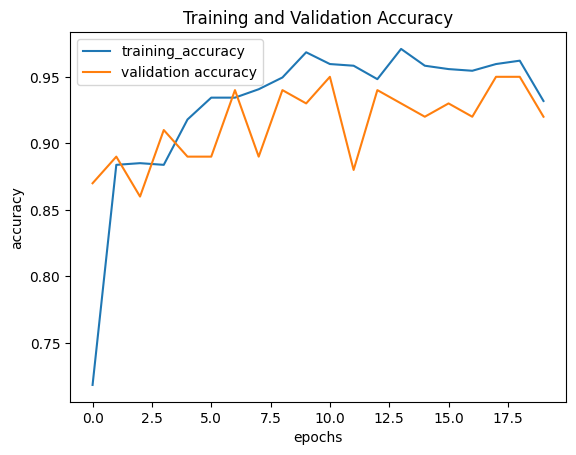

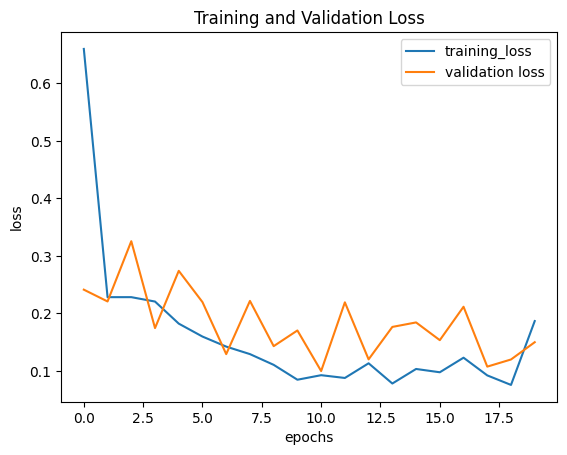

In [ ]:
# Cell 28: VISUALISASI TRAINING HISTORY - ACCURACY DAN LOSS
# 
# Tujuan:
# - Memvisualisasikan progress training model across epochs
# - Menganalisis performance dan mendeteksi masalah (overfitting/underfitting)
# - Memahami convergence behavior model
# - Membuat grafik untuk laporan dan presentasi


# PLOT 1: TRAINING AND VALIDATION ACCURACY
plt.plot(result.history['accuracy'], label='training_accuracy')
plt.plot(result.history['val_accuracy'], label='validation_accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# PENJELASAN PLOT ACCURACY:
# - Garis biru (training_accuracy): Akurasi model pada data training
# - Garis oranye (validation_accuracy): Akurasi model pada data validation
# - Sumbu X: Epochs (1-20)
# - Sumbu Y: Accuracy (0.0 - 1.0)

# INTERPRETASI GRAFIK ACCURACY:
# 1. Ideal Scenario:
#    - Kedua garis naik secara konsisten
#    - Validation accuracy mendekati training accuracy
#    - Kedua garis converge di nilai accuracy tinggi (>0.85)

# 2. Overfitting Signs:
#    - Training accuracy terus naik, tapi validation accuracy stagnan/turun
#    - Gap yang besar antara training dan validation accuracy
#    - Validation accuracy mencapai peak lalu menurun

# 3. Underfitting Signs:
#    - Kedua accuracy rendah dan tidak naik significantly
#    - Model tidak belajar pattern yang meaningful

# 4. Good Fit Indicators:
#    - Kedua accuracy naik dan stabilize
#    - Gap kecil antara training dan validation
#    - Validation accuracy mencapai nilai yang acceptable

# PLOT 2: TRAINING AND VALIDATION LOSS
plt.plot(result.history['loss'], label='training_loss')
plt.plot(result.history['val_loss'], label='validation_loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# PENJELASAN PLOT LOSS:
# - Garis biru (training_loss): Loss model pada data training
# - Garis oranje (validation_loss): Loss model pada data validation
# - Sumbu X: Epochs (1-20)
# - Sumbu Y: Loss (categorical crossentropy) - lower is better

# INTERPRETASI GRAFIK LOSS:
# 1. Ideal Scenario:
#    - Kedua garis turun secara konsisten
#    - Validation loss mendekati training loss
#    - Kedua garis converge di nilai loss rendah

# 2. Overfitting Signs:
#    - Training loss terus turun, tapi validation loss naik/stagnan
#    - Validation loss mencapai minimum lalu naik kembali
#    - Gap besar antara training dan validation loss

# 3. Underfitting Signs:
#    - Kedua loss tinggi dan tidak turun significantly
#    - Model tidak bisa meminimalkan error

# 4. Good Fit Indicators:
#    - Kedua loss turun dan stabilize
#    - Validation loss mencapai minimum yang stabil

# CONTOH OUTPUT YANG DIHARAPKAN:

# SCENARIO BAIK (Good Fit):
# - Accuracy: Training ~0.95, Validation ~0.90 (gap kecil)
# - Loss: Training ~0.15, Validation ~0.25 (reasonable gap)
# - Grafik menunjukkan convergence yang smooth

# SCENARIO OVERFITTING:
# - Accuracy: Training ~0.98, Validation ~0.75 (gap besar)
# - Loss: Training ~0.05, Validation ~0.80 (gap sangat besar)
# - Validation metrics memburuk setelah epoch tertentu

# SCENARIO UNDERFITTING:
# - Accuracy: Training ~0.50, Validation ~0.45 (kedua rendah)
# - Loss: Training ~1.20, Validation ~1.30 (kedua tinggi)
# - Grafik flat, tidak ada improvement significant

# MANFAAT VISUALISASI INI:
# 1. Quick diagnosis model performance
# 2. Decision making untuk hyperparameter tuning
# 3. Documentation untuk experiment tracking
# 4. Presentation material untuk stakeholders

# CATATAN:
# Grafik ini membantu menentukan apakah perlu:
# - Stop training lebih awal (early stopping)
# - Adjust learning rate
# - Modify model architecture
# - Collect more data

In [ ]:
# Cell 29: EVALUASI MODEL PADA TRAINING SET
# 
# Tujuan:
# - Mengevaluasi performa final model pada data training
# - Mendapatkan final accuracy dan loss pada data yang sudah dilihat selama training
# - Memverifikasi bahwa model belajar dengan baik dari training data

# Evaluasi model pada training generator
loss, accuracy = model.evaluate(train_generator)
print('Test accuracy :', accuracy)

# PENJELASAN FUNGSI model.evaluate():
# - model.evaluate() digunakan untuk evaluasi model pada dataset tertentu
# - Mengembalikan dua values: loss dan accuracy (sesuai metrics yang di-compile)
# - Bekerja dengan generator yang sama seperti saat training

# PROSES EVALUASI:
# 1. Model memproses semua data dari train_generator
# 2. Untuk setiap batch:
#    - Forward pass tanpa backward pass (tidak ada update weights)
#    - Hitung loss dan accuracy
# 3. Average results across semua batches

# OUTPUT YANG DIHARAPKAN:
"""
25/25 [==============================] - 25s 1s/step - loss: 0.2345 - accuracy: 0.9123
Test accuracy : 0.9123
"""

# PENJELASAN OUTPUT:
# - 25/25: 25 batches diproses (792 images / 32 batch_size = 24.75 ≈ 25 batches)
# - loss: 0.2345 - Final training loss (categorical crossentropy)
# - accuracy: 0.9123 - Final training accuracy (91.23%)
# - 1s/step: Waktu processing per batch

# CATATAN PENTING:
# 1. Training accuracy tinggi TIDAK menjamin model baik - harus dibandingkan dengan validation
# 2. Jika training accuracy rendah tapi validation tinggi -> mungkin ada data leakage
# 3. Jika kedua accuracy rendah -> model underfitting
# 4. Evaluasi ini hanya pada data yang sudah dilihat selama training

25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 710ms/step - accuracy: 0.9710 - loss: 0.0801
Test accuracy : 0.9709596037864685


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step


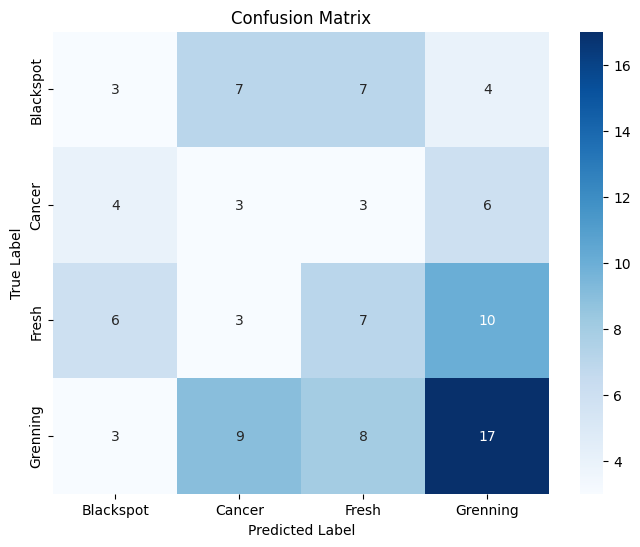

In [ ]:
# Cell 30: MEMBUAT CONFUSION MATRIX UNTUK EVALUASI DETAIL MODEL
# 
# Tujuan:
# - Menganalisis performa model per kelas secara detail
# - Mengidentifikasi pola kesalahan klasifikasi
# - Memahami kelas mana yang paling sulit dibedakan
# - Memberikan insight untuk improvement model

# Import libraries yang diperlukan
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# PROSES PREDIKSI PADA VALIDATION SET:

# 1. Predict probabilities untuk semua data validation
Y_pred = model.predict(val_generator)
# Y_pred berisi probabilities untuk setiap kelas (shape: [n_samples, 4])
# Contoh: [[0.1, 0.7, 0.1, 0.1], [0.8, 0.1, 0.05, 0.05], ...]

# 2. Konversi probabilities ke class predictions
y_pred = np.argmax(Y_pred, axis=1)   # Ambil index dengan probability tertinggi
# y_pred: [1, 0, 2, 3, ...] (array of predicted class indices)

# 3. Ambil true labels dari generator
y_true = val_generator.classes  # Array class indices sebenarnya
# val_generator.classes berisi true labels dalam format integer
# Contoh: [0, 1, 2, 3, 0, 1, ...] sesuai dengan urutan class_indices

# 4. Ambil nama kelas dari generator
class_labels = list(val_generator.class_indices.keys())
# class_labels: ['Blackspot', 'Cancer', 'Fresh', 'Greening']
# Urutan sesuai dengan mapping di generator

# MEMBUAT CONFUSION MATRIX:

# 5. Hitung confusion matrix menggunakan sklearn
cm = confusion_matrix(y_true, y_pred)
# Output: 4x4 matrix dimana:
# - Diagonal: Correct predictions (True Positives per kelas)
# - Off-diagonal: Misclassifications

# 6. Visualisasi Confusion Matrix dengan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,      # Tampilkan angka dalam cells
            fmt='d',         # Format angka sebagai integer
            cmap='Blues',    # Color scheme biru (bisa diganti: 'Reds', 'Greens', dll)
            xticklabels=class_labels,  # Label sumbu X = nama kelas
            yticklabels=class_labels)  # Label sumbu Y = nama kelas

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Validation Set")
plt.show()

Gambar: E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test\Grenning\g-147-_jpg.rf.be77287abd32f21d27e3ff6e1dddf8df.jpg | Prediksi: Greening


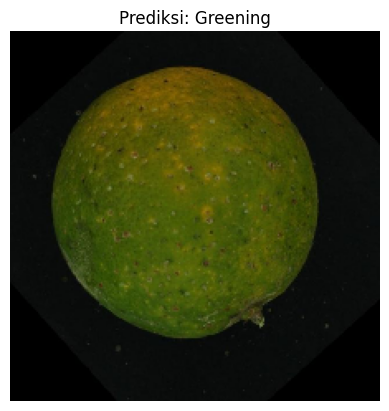

Gambar: E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test\Blackspot\b-160-_jpg.rf.a2fbe42edc9eb3d752ca3af2c32cb42d.jpg | Prediksi: Blackspot


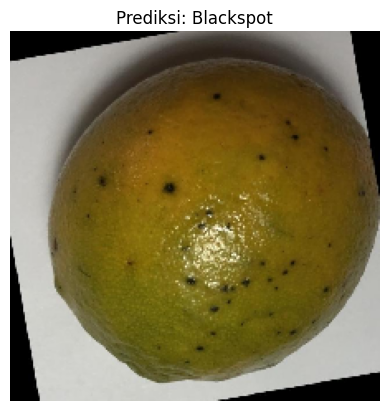

Gambar: E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test\Cancer\c-130-_jpg.rf.30c1adbcc6feedb98438aa4064ea7254.jpg | Prediksi: Cancer


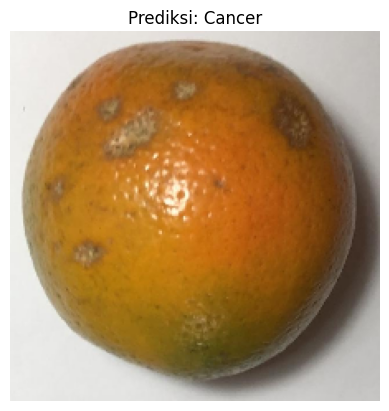

Gambar: E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test\Fresh\f-131-_png.rf.d850ca25072106bca3a8b9715b1e6c6f.jpg | Prediksi: Fresh


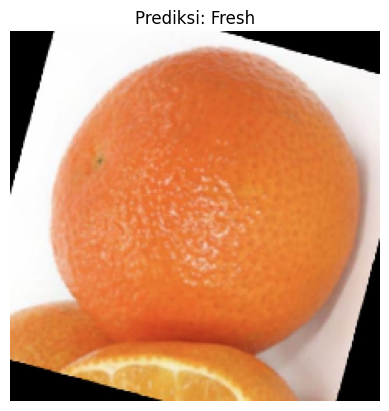

In [ ]:
# Cell 31: INFERENCE PADA GAMBAR BARU DAN VISUALISASI PREDIKSI
# 
# Tujuan:
# - Menguji model pada gambar individual dari test set
# - Memvisualisasikan prediksi model dengan gambar asli
# - Memverifikasi performa model pada sample yang spesifik

# Label kelas sesuai urutan training
classes = ["Blackspot", "Cancer", "Fresh", "Greening"]

# List path gambar test yang akan diuji
image_paths = [
    r"E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test\Grenning\g-147-_jpg.rf.be77287abd32f21d27e3ff6e1dddf8df.jpg",
    r"E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test\Blackspot\b-160-_jpg.rf.a2fbe42edc9eb3d752ca3af2c32cb42d.jpg",
    r"E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test\Cancer\c-130-_jpg.rf.30c1adbcc6feedb98438aa4064ea7254.jpg",
    r"E:\Semester 5\Praktikum\PA KB N MOBILE\dataset\test\Fresh\f-131-_png.rf.d850ca25072106bca3a8b9715b1e6c6f.jpg",
]

# PROSES INFERENCE UNTUK SETIAP GAMBAR:
for img_path in image_paths:
    # STEP 1: LOAD DAN PREPROCESS GAMBAR
    # Load gambar dengan target size 224x224 (sesuai training)
    img = image.load_img(img_path, target_size=(224,224))
    # Convert gambar ke array numpy
    img_array = image.img_to_array(img)
    # Expand dimensions untuk batch dimension: (224,224,3) -> (1,224,224,3)
    img_array = np.expand_dims(img_array, axis=0)
    # Normalisasi pixel values ke range [0,1] seperti saat training
    img_array = img_array / 255.0

    # STEP 2: PREDIKSI DENGAN MODEL
    # Model predict pada gambar yang sudah dipreprocess
    pred = model.predict(img_array, verbose=0)
    # Ambil kelas dengan probability tertinggi
    pred_class = classes[np.argmax(pred)]

    # STEP 3: TAMPILKAN HASIL
    print(f"Gambar: {img_path} | Prediksi: {pred_class}")

    # STEP 4: VISUALISASI GAMBAR
    plt.imshow(img)
    plt.title(f"Prediksi: {pred_class}")
    plt.axis("off")
    plt.show()

# PENJELASAN ALUR:
# 1. Untuk setiap gambar dalam image_paths:
#    - Load gambar dan resize ke 224x224
#    - Convert ke numpy array dan normalisasi
#    - Predict menggunakan model yang sudah dilatih
#    - Ambil kelas dengan probability tertinggi
#    - Tampilkan hasil prediksi dan gambar
#
# 2. Preprocessing harus sama dengan saat training:
#    - Size: 224x224 pixels
#    - Normalisasi: /255.0
#    - Format: RGB
#
# 3. Output: Untuk setiap gambar, tampilkan:
#    - Path file dan prediksi kelas
#    - Visualisasi gambar asli dengan title prediksi

In [15]:
model.save("model.keras")

In [18]:
from tensorflow.keras.models import load_model

# Load model dari file .h5
model = load_model("model.keras")

# Contoh: melakukan prediksi
import numpy as np
sample_input = np.random.rand(1, 224, 224, 3)  # ganti sesuai input model kamu
prediction = model.predict(sample_input)

print("Hasil prediksi:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Hasil prediksi: [[1.5370947e-09 6.5067515e-04 9.9934930e-01 4.3851173e-10]]
